In [ ]:
%pip install ahrs

In [1]:
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '../..'))

In [2]:
import pandas as pd
import numpy as np
from scipy.integrate import cumulative_trapezoid
import matplotlib.pyplot as plt
from ahrs.filters import Madgwick
from ahrs import QuaternionArray

In [16]:
DATA_PATH="../../data/IMU_data/u_shape.csv"
FILENAME=DATA_PATH.split("/")[-1].split(".")[0]

df = pd.read_csv(DATA_PATH)
df.head()

,timestamp,esp32_micros,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,1.776077e+09,8000000,-1.1480,0.0886,9.2225,-0.0428,-0.0132,-0.0416
1,1.776077e+09,8010000,-1.2019,0.1496,9.3625,-0.0252,-0.0352,0.0047
2,1.776077e+09,8020000,-1.4664,-0.0778,9.3829,-0.0260,-0.0092,-0.0282
3,1.776077e+09,8030000,-1.2917,0.0168,9.3242,-0.0352,0.0021,-0.0460
4,1.776077e+09,8040000,-1.2797,0.0108,9.2835,-0.0317,0.0019,-0.0334


In [17]:
t = df['timestamp'].values
a_x, a_y, a_z = df['accel_x'].values, df['accel_y'].values, df['accel_z'].values
g_x, g_y, g_z = df['gyro_x'].values, df['gyro_y'].values, df['gyro_z'].values.copy()

In [18]:
class SimpleKalman:
    def __init__(self, process_noise=0.001, measurement_noise=0.03):
        self.angle = 0.0
        self.p = 1.0  # Error covariance
        self.q = process_noise      # Q: Gyro drift tolerance
        self.r = measurement_noise  # R: Accel noise tolerance

    def update(self, gyro_rate, accel_angle, dt):
        # 1. PREDICT (Trust Gyro)
        self.angle += gyro_rate * dt
        self.p += self.q
        
        # 2. KALMAN GAIN
        k = self.p / (self.p + self.r)
        
        # 3. UPDATE (Trust Accel)
        self.angle += k * (accel_angle - self.angle)
        self.p *= (1 - k)
        
        return self.angle

In [19]:
# dt = np.mean(np.diff(t))

# g_x = g_x - g_x[0]
# g_y = g_y - g_y[0]
# g_z = g_z -  g_z[0]

# gyro_data = np.column_stack((g_x, g_y, g_z))
# accel_data = np.column_stack((a_x, a_y, a_z))

In [20]:
# madgwick = Madgwick(gyr=gyro_data, acc=accel_data, Dt=dt, gain=0.033)
# Q = madgwick.Q 
# R = QuaternionArray(Q).to_DCM()

# global_accel = np.zeros_like(accel_data)
# for i in range(len(t)):
#     global_accel[i] = R[i] @ accel_data[i]

In [21]:
# global_accel[:, 2] -= 9.81

In [22]:
# initial_roll = np.arctan2(a_y[0], a_z[0])
# initial_pitch = np.arctan2(-a_x[0], np.sqrt(a_y[0]**2 + a_z[0]**2))
# initial_yaw = 0.0 

In [23]:
# roll_changes = cumulative_trapezoid(g_x, x=t, initial=0)
# pitch_changes = cumulative_trapezoid(g_y, x=t, initial=0)
# yaw_changes = cumulative_trapezoid(g_z, x=t, initial=0)

# roll = initial_roll + roll_changes
# pitch = initial_pitch + pitch_changes
# yaw = initial_yaw + yaw_changes

In [24]:
accel_roll = np.arctan2(a_y, a_z)
accel_pitch = np.arctan2(-a_x, np.sqrt(a_y**2 + a_z**2))

kf_roll = SimpleKalman()
kf_pitch = SimpleKalman()

kf_roll.angle = accel_roll[0]
kf_pitch.angle = accel_pitch[0]

roll = np.zeros(len(t))
pitch = np.zeros(len(t))
roll[0] = accel_roll[0]
pitch[0] = accel_pitch[0]

for i in range(1, len(t)):
    dt = t[i] - t[i-1]
    roll[i] = kf_roll.update(g_x[i], accel_roll[i], dt)
    pitch[i] = kf_pitch.update(g_y[i], accel_pitch[i], dt)

yaw_changes = cumulative_trapezoid(g_z, x=t, initial=0)
yaw = 0.0 + yaw_changes

In [25]:
true_a_x = a_x - (9.81 * np.sin(pitch))
true_a_y = a_y - (9.81 * np.sin(roll))
true_a_z = a_z - (9.81 * np.cos(pitch) * np.cos(roll))

global_a_x = (true_a_x * np.cos(yaw)) - (true_a_y * np.sin(yaw))
global_a_y = (true_a_x * np.sin(yaw)) + (true_a_y * np.cos(yaw))
global_a_z = true_a_z

In [ ]:
v_x = cumulative_trapezoid(global_a_x, x=t, initial=0)
v_y = cumulative_trapezoid(global_a_y, x=t, initial=0)
v_z = cumulative_trapezoid(global_a_z, x=t, initial=0)


p_x = cumulative_trapezoid(v_x, x=t, initial=0)
p_y = cumulative_trapezoid(v_y, x=t, initial=0)
p_z = cumulative_trapezoid(v_z, x=t, initial=0)

In [27]:
# v_x = cumulative_trapezoid(global_accel[:, 0], x=t, initial=0)
# v_y = cumulative_trapezoid(global_accel[:, 1], x=t, initial=0)
# v_z = cumulative_trapezoid(global_accel[:, 2], x=t, initial=0)

# p_x = cumulative_trapezoid(v_x, x=t, initial=0)
# p_y = cumulative_trapezoid(v_y, x=t, initial=0)
# p_z = cumulative_trapezoid(v_z, x=t, initial=0)

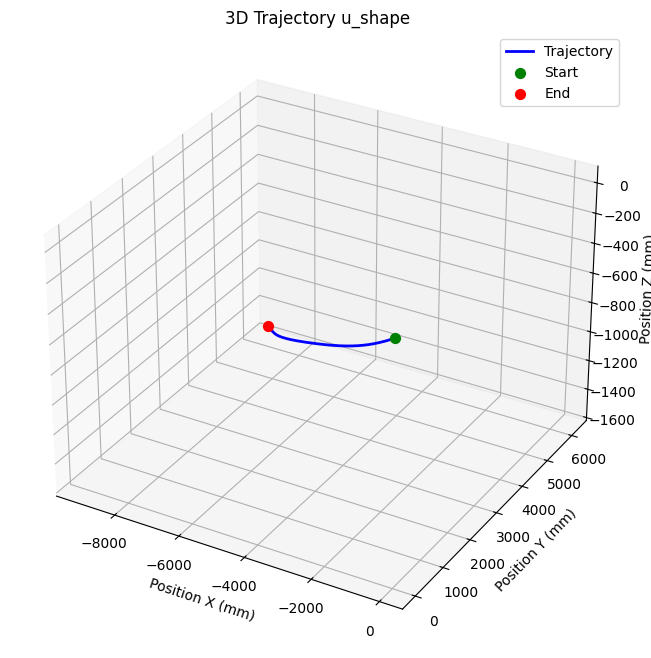

In [28]:
SAVE_PATH=f"../../Simulations/IMU_trajectories/{FILENAME}.png"

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(p_x, p_y, p_z, label='Trajectory', color='blue', linewidth=2)

ax.scatter(p_x[0], p_y[0], p_z[0], color='green', s=50, label='Start')
ax.scatter(p_x[-1], p_y[-1], p_z[-1], color='red', s=50, label='End')

ax.set_xlabel('Position X (mm)')
ax.set_ylabel('Position Y (mm)')
ax.set_zlabel('Position Z (mm)')
ax.set_title(f'3D Trajectory {FILENAME}')
ax.legend()

fig.savefig(SAVE_PATH)

plt.show()
